# Dust Data Exploration with Meteorological Features
This notebook explores `data_sfc.nc` (PM10) and merges it with ERA5 meteorological data.
It includes:
- Seasonal Analysis
- 3-Year Time Series Plots
- **Animated Map of PM10 Concentration**


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set plot style
plt.style.use('ggplot')


In [3]:
# Load PM10 Data
ds_pm10 = xr.open_dataset('../data/data_sfc.nc')

# Load ERA5 Data (if available)
try:
    ds_era5 = xr.open_dataset('../data/era5_data.nc')
    # Merge datasets
    ds = xr.merge([ds_pm10, ds_era5], join='inner')
    print("Merged Dataset created.")
except FileNotFoundError:
    print("WARNING: 'era5_data.nc' not found. Using PM10 data only.")
    ds = ds_pm10


In [4]:
def get_astronomical_season(date):
    year = date.year
    spring_equinox = pd.Timestamp(year=year, month=3, day=20)
    summer_solstice = pd.Timestamp(year=year, month=6, day=21)
    autumn_equinox = pd.Timestamp(year=year, month=9, day=22)
    winter_solstice = pd.Timestamp(year=year, month=12, day=21)
    
    dt = pd.Timestamp(date)
    
    if dt < spring_equinox:
        return 'Winter'
    elif spring_equinox <= dt < summer_solstice:
        return 'Spring'
    elif summer_solstice <= dt < autumn_equinox:
        return 'Summer'
    elif autumn_equinox <= dt < winter_solstice:
        return 'Autumn'
    else:
        return 'Winter'

def add_astronomical_season(ds):
    if 'valid_time' in ds.coords:
        time_index = pd.to_datetime(ds.valid_time.values)
    else:
        raise ValueError("No valid time coordinate found")

    seasons = [get_astronomical_season(t) for t in time_index]
    ds['season'] = (('valid_time'), seasons)
    return ds

ds = add_astronomical_season(ds)


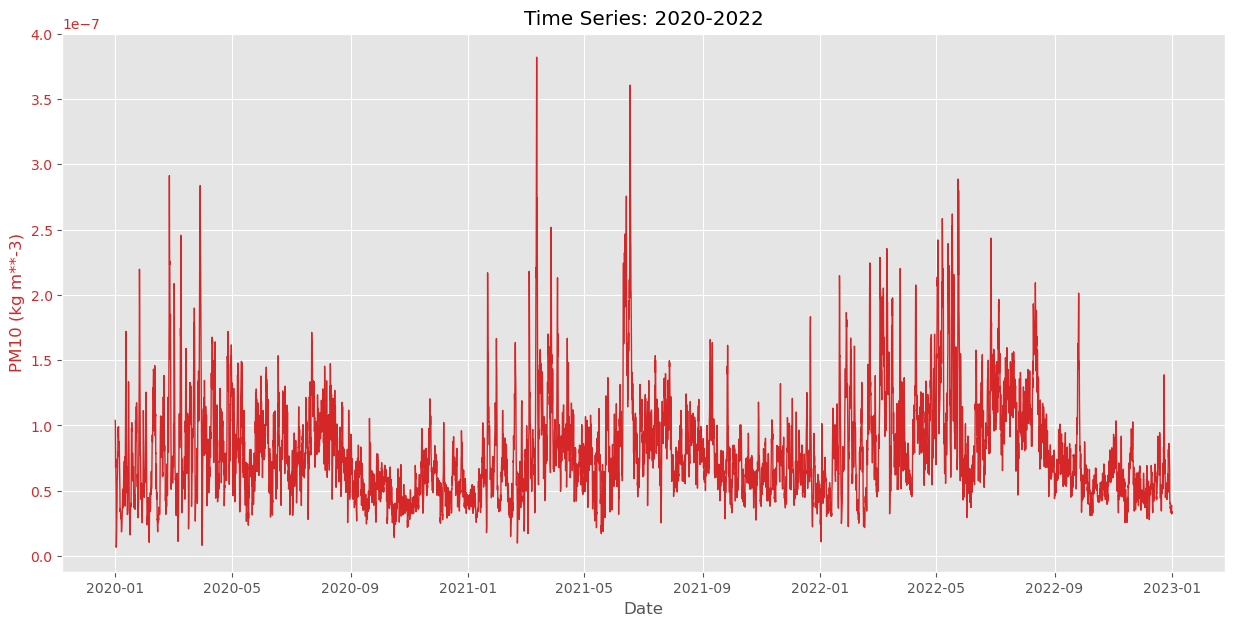

In [5]:
# --- 3-Year Time Series Visualization ---
start_year = 2020
end_year = 2022
start_date = f'{start_year}-01-01'
end_date = f'{end_year}-12-31'

ds_subset = ds.sel(valid_time=slice(start_date, end_date))
df_subset = ds_subset.mean(dim=['latitude', 'longitude']).to_dataframe()

fig, ax1 = plt.subplots(figsize=(15, 7))
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('PM10 (kg m**-3)', color=color)
ax1.plot(df_subset.index, df_subset['pm10'], color=color, linewidth=1, label='PM10')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title(f'Time Series: {start_year}-{end_year}')
plt.show()


## PM10 Map Animation
Run the cell below to generate an interactive map animation.

In [ ]:
# --- Animated Map of PM10 (Saudi Arabia Region) ---
# Settings
anim_start_year = 2020
anim_end_year = 2020  # Keep it short for smoother rendering, expand as needed
# Select data
anim_subset = ds.sel(valid_time=slice(f'{anim_start_year}-01-01', f'{anim_end_year}-12-31'))

# Downsample for speed (optional, e.g., daily mean)
anim_subset_daily = anim_subset.resample(valid_time='1D').mean()

# Setup Figure and Map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])

# Initial Plot
# Using 'YlOrBr' colormap for "Yellow" dust appearance
pm10_min = anim_subset_daily['pm10'].min().values
pm10_max = anim_subset_daily['pm10'].max().values

mesh = ax.pcolormesh(anim_subset_daily.longitude, anim_subset_daily.latitude, 
                     anim_subset_daily['pm10'].isel(valid_time=0),
                     transform=ccrs.PlateCarree(),
                     cmap='YlOrBr', vmin=pm10_min, vmax=pm10_max, shading='auto')

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('PM10 Concentration (kg m**-3)')
title = ax.set_title(f"PM10 - {str(anim_subset_daily.valid_time.values[0])[:10]}")

def update(frame):
    data = anim_subset_daily['pm10'].isel(valid_time=frame)
    mesh.set_array(data.values.ravel())
    title.set_text(f"PM10 - {str(anim_subset_daily.valid_time.values[frame])[:10]}")
    return mesh, title

# Create Animation
print(f"Generating animation for {len(anim_subset_daily.valid_time)} frames...")
anim = animation.FuncAnimation(fig, update, frames=len(anim_subset_daily.valid_time), interval=200, blit=False)

# Display as HTML5 Video (requires ffmpeg usually, or use jshtml)
HTML(anim.to_jshtml())
